In [4]:
import os
from SSD_eval.SSD_utils import get_project_root
from pathlib import Path
import sys
from ipywidgets import interact

os.chdir(get_project_root())

ssd_eval_path = str(Path.cwd() / "SSD_eval")
if ssd_eval_path not in sys.path:
    sys.path.insert(0, ssd_eval_path)

from SSD_eval.SSD_test_utils import *

%matplotlib widget

Loading model from checkpoint: checkpoints/syn/test_biased_00/checkpoints/last.ckpt
Loaded default weights from checkpoints/syn/test_biased_00/checkpoints/last.ckpt
tensor([[ 1.0000,  0.0000,  0.0000, -0.4444, -0.1111, -0.7143, -0.6711,  0.7413],
        [ 0.0000,  1.0000,  0.0000,  0.8889,  0.5556,  0.7143,  0.2991, -0.9542],
        [ 1.0000,  0.0000,  0.0000, -0.7778, -0.6667, -0.7143,  0.6047, -0.7965]],
       device='cuda:0')
tensor([[ 5.2055, -3.5852, -6.1101, -0.4455, -0.0961, -0.7376, -0.6485,  0.8183],
        [-3.1764,  6.3332, -5.4992,  0.8759,  0.5528,  0.6538,  0.3102, -0.9341],
        [ 5.6672, -5.0956, -6.3748, -0.7776, -0.6512, -0.7510,  0.6186, -0.7498]],
       device='cuda:0', grad_fn=<SliceBackward0>)


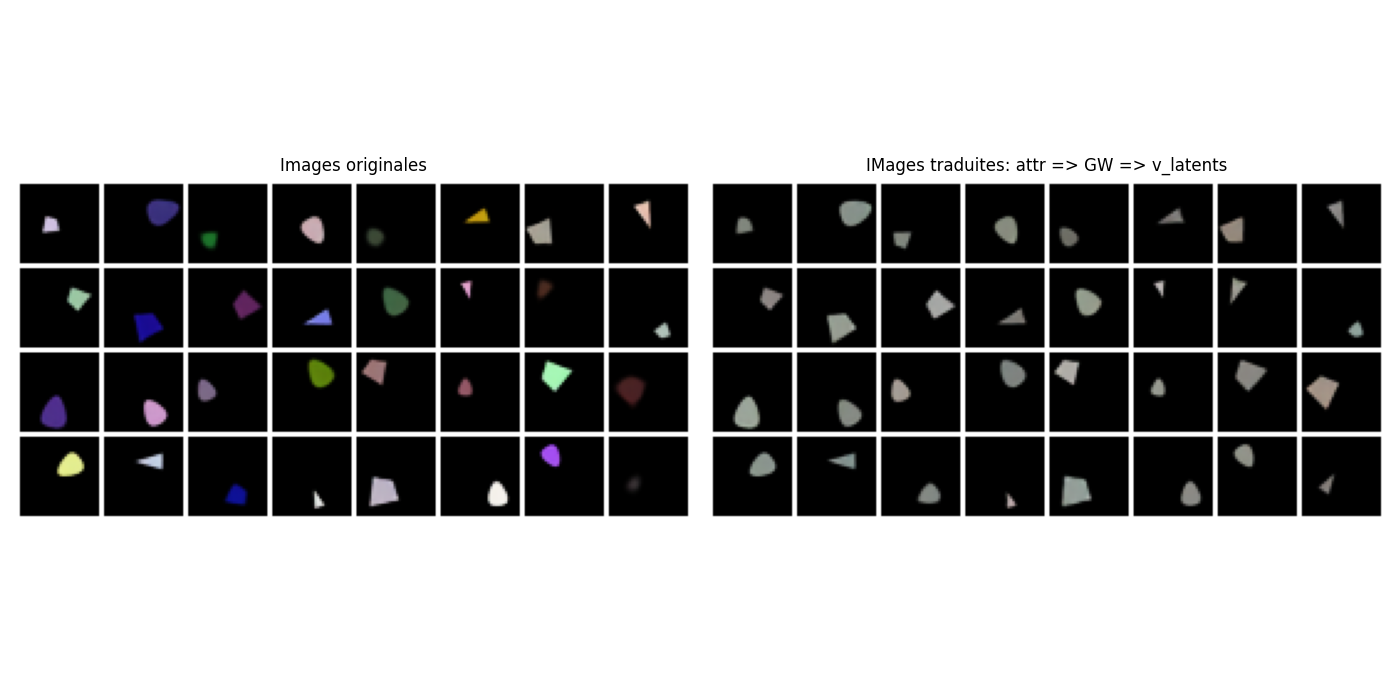

In [ ]:
condition = "test"
data = "biased_00"

n_samples = 32
show_results_fusion = True
fusion_attr_weight = 1.0

project_name = "syn"
experiment_name = f"{condition}_{data}"


training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name)
data_module = get_data_module(project_name,  experiment_name)
train_samples = get_data_samples(data_module, n_samples, noise = 0.05)
data_translated = get_data_translated(global_workspace, train_samples, n_samples, fusion_attr_weight, show_results_fusion)

print(data_translated["train_attr"][0:3])
print(data_translated["attr_decoded"][0:3])
plot_original_translated_comparison(data_translated["train_images"], data_translated["images_decoded"])

In [ ]:
print(train_samples)



{frozenset({'attr'}): {'attr': [tensor([[9.5257e-01, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.0605e+00, 0.0000e+00],
        [9.7519e-01, 0.0000e+00, 2.0274e-02],
        [5.7039e-02, 1.0137e+00, 0.0000e+00],
        [3.2076e-03, 1.0838e+00, 0.0000e+00],
        [0.0000e+00, 7.4902e-03, 1.0516e+00],
        [9.3886e-01, 0.0000e+00, 4.5179e-02],
        [0.0000e+00, 2.1972e-02, 1.0178e+00],
        [1.0279e+00, 0.0000e+00, 0.0000e+00],
        [9.6074e-01, 9.6635e-02, 5.9588e-02],
        [9.9880e-01, 0.0000e+00, 0.0000e+00],
        [1.8073e-02, 4.9550e-04, 8.4770e-01],
        [0.0000e+00, 1.0957e+00, 0.0000e+00],
        [2.9010e-02, 0.0000e+00, 9.8754e-01],
        [0.0000e+00, 9.2557e-02, 9.7683e-01],
        [8.4951e-01, 8.6511e-02, 0.0000e+00],
        [0.0000e+00, 1.0601e+00, 0.0000e+00],
        [1.1385e-01, 1.0113e+00, 4.8086e-02],
        [0.0000e+00, 1.0115e+00, 2.1192e-02],
        [0.0000e+00, 9.6148e-01, 0.0000e+00],
        [1.0443e+00, 3.2613e-02, 5.6917e-02],
  

In [29]:
@interact(
    cat=["Triangle", "Egg", "Diamond"],
    x=(0, 1, 0.1),
    y=(0, 1, 0.1),
    rot=(0, 1, 0.1),
    size=(0, 1, 0.1),
    color_r=(0, 1, 0.1),
    color_g=(0, 1, 0.1),
    color_b=(0, 1, 0.1),
)
def play_with_gw(
    cat: str = "Triangle",
    x: float = 0.5,
    y: float = 0.5,
    rot: float = 0.5,
    size: float = 0.5,
    color_r: float = 1,
    color_g: float = 0,
    color_b: float = 0,
):
    original_image = get_image(cat, x, y, size, rot, color_r, color_g, color_b)
    decoded_image = get_decoded_image(cat, x, y, size, rot, color_r, color_g, color_b, training_params, device, global_workspace)
    plot_interactive(original_image, decoded_image)



interactive(children=(Dropdown(description='cat', options=('Triangle', 'Egg', 'Diamond'), value='Triangle'), F…